# Classification: Random Forest (Bagging Ensemble of Trees)

This notebook builds a survival classifier on the [Titanic dataset](https://www.kaggle.com/c/titanic) using a **Random Forest** — a **bagging** ensemble of many Decision Trees, each trained on a bootstrap sample of the data with a random subset of features considered at each split.

This follows the same pipeline as the single Decision Tree notebook, so the data prep is identical -- the interesting differences are in the model itself:
1. Get the data
2. Profile the data
3. Clean the data
4. Transform the data (encode categoricals -- no scaling needed for trees)
5. Split into train / validation / test
6. Build the model: **a Random Forest (bagging ensemble)**
7. **See bagging reduce overfitting** vs. the single tree, using the built-in **out-of-bag (OOB) score**
8. Tune `n_estimators` and `max_depth` using the validation set
9. Final evaluation on the held-out test set
10. Compare feature importances: single tree vs. forest
11. Inference on a new, unseen passenger
12. Save the model

## 0. Install & Import Libraries

In [1]:
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib --quiet

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve,
)
import joblib

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Libraries loaded.")


Libraries loaded.


## 1. Get the Data

Loading the dataset from a local cache under `data/` if it exists; otherwise downloading it from the public source below and saving a local copy for next time:

`https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv`

Each row is one passenger; the target column is `Survived` (`0` = died, `1` = survived).

In [2]:
DATA_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
DATA_DIR = "data"
LOCAL_PATH = os.path.join(DATA_DIR, "titanic.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(LOCAL_PATH):
    print(f"Loading data from local cache: {LOCAL_PATH}")
    df_raw = pd.read_csv(LOCAL_PATH)
else:
    print(f"Local file not found. Downloading from {DATA_URL} ...")
    df_raw = pd.read_csv(DATA_URL)
    df_raw.to_csv(LOCAL_PATH, index=False)
    print(f"Saved local copy to: {LOCAL_PATH}")

print("Shape:", df_raw.shape)
df_raw.head()


Local file not found. Downloading from https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv ...
Saved local copy to: data/titanic.csv
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Profile the Data

In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
print("Survival distribution:")
print(df_raw["Survived"].value_counts(normalize=True).rename("proportion"))

print("\nNull count per column:")
print(df_raw.isna().sum())


Survival distribution:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Null count per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


`Age` has a lot of missing values, `Cabin` is missing for most passengers, and `Embarked` is missing for a couple. `PassengerId`, `Name`, and `Ticket` are unique/near-unique identifiers with no real predictive value, so they get dropped.

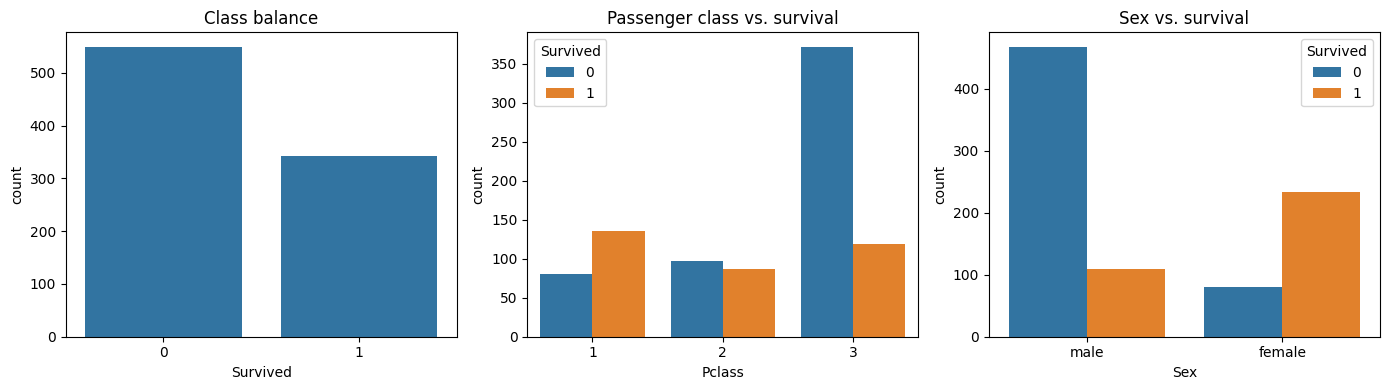

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(data=df_raw, x="Survived", ax=axes[0])
axes[0].set_title("Class balance")

sns.countplot(data=df_raw, x="Pclass", hue="Survived", ax=axes[1])
axes[1].set_title("Passenger class vs. survival")

sns.countplot(data=df_raw, x="Sex", hue="Survived", ax=axes[2])
axes[2].set_title("Sex vs. survival")

plt.tight_layout()
plt.show()


## 3. Clean the Data

Same cleaning as the single-tree notebook:
1. Check for **true duplicates first**, while unique identifiers (`PassengerId`, `Name`, `Ticket`) are still present -- checking after dropping them would flag coincidental feature matches as false-positive "duplicates".
2. Drop `PassengerId`, `Name`, `Ticket` (identifiers) and `Cabin` (too sparse -- missing for ~77% of passengers).
3. `Age` and `Embarked` missing values are left as-is here and imputed later in the transform step (fit on train only).

In [6]:
df = df_raw.copy()

# 1. Check for true duplicate passengers FIRST, before dropping identifier columns
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} true duplicate rows -> {len(df)} rows remaining")

# 2. Drop identifier / low-value columns
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

print("\nRemaining missing values (to be imputed later, fit on train only):")
print(df.isna().sum()[df.isna().sum() > 0])


Dropped 0 true duplicate rows -> 891 rows remaining

Remaining missing values (to be imputed later, fit on train only):
Age         177
Embarked      2
dtype: int64


## 4. Transform the Data: Encode Categoricals

Like the single Decision Tree, a Random Forest doesn't need feature scaling -- each individual tree in the forest still just asks yes/no threshold questions. We still need to **encode categoricals** (`Sex`, `Embarked`) and **impute missing values** (`Age`, `Embarked`).

In [7]:
target_col = "Survived"
feature_cols = [c for c in df.columns if c != target_col]
numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
categorical_features = [c for c in feature_cols if c not in numeric_features]

print("Numeric features    :", numeric_features)
print("Categorical features:", categorical_features)


Numeric features    : ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical features: ['Sex', 'Embarked']


In [8]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 5. Split into Train / Validation / Test

In [9]:
X = df[numeric_features + categorical_features]
y = df[target_col]

TEST_SIZE = 0.2
VAL_SIZE = 0.1

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y,
)

val_fraction_of_temp = VAL_SIZE / (1 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_fraction_of_temp, random_state=SEED, stratify=y_temp,
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (623, 7), Val: (89, 7), Test: (179, 7)


In [10]:
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

feature_names_out = preprocessor.get_feature_names_out()
print("Processed feature count:", len(feature_names_out))
print(feature_names_out)


Processed feature count: 10
['num__Pclass' 'num__Age' 'num__SibSp' 'num__Parch' 'num__Fare'
 'cat__Sex_female' 'cat__Sex_male' 'cat__Embarked_C' 'cat__Embarked_Q'
 'cat__Embarked_S']


## 6. Build the Model: Random Forest (Bagging)

A single Decision Tree is a "high-variance" model -- small changes in the training data can produce a very different tree, and an unconstrained tree tends to overfit badly (you saw this directly in the previous notebook: ~98.6% train accuracy vs. ~74% validation accuracy).

**Bagging** (bootstrap aggregating) tackles this by training many trees, each on a different **bootstrap sample** (random sample with replacement, same size as the original training set) of the data, then **averaging their votes**. Averaging many high-variance, low-bias trees cancels out each individual tree's overfit quirks, producing a much more stable prediction.

`RandomForestClassifier` adds one more trick on top of plain bagging: at each split, instead of considering all features, it only considers a **random subset** of them (`max_features`, default `sqrt(n_features)` for classification). This decorrelates the trees further -- without it, if one feature is very strong (e.g. `Sex`), nearly every tree would split on it first and the trees would end up highly correlated with each other, which weakens the averaging benefit.

In [11]:
baseline_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1,
    oob_score=True,   # score each tree on the rows it did NOT see (bootstrapped out)
)
baseline_rf.fit(X_train_proc, y_train)

train_preds = baseline_rf.predict(X_train_proc)
val_preds = baseline_rf.predict(X_val_proc)

print("Baseline RF train accuracy     :", round(accuracy_score(y_train, train_preds), 4))
print("Baseline RF validation accuracy:", round(accuracy_score(y_val, val_preds), 4))
print("Baseline RF OOB accuracy       :", round(baseline_rf.oob_score_, 4))


Baseline RF train accuracy     : 0.9856
Baseline RF validation accuracy: 0.8652
Baseline RF OOB accuracy       : 0.8138


## 7. Out-of-Bag (OOB) Score -- a Free Validation Estimate

Each bootstrap sample leaves out roughly **1/3 of the training rows** on average (sampling with replacement from N rows, the probability any given row is *never* picked is `(1 - 1/N)^N` -> converges to `1/e` ≈ 36.8% as N grows). Those left-out rows are called **out-of-bag** for that tree.

`oob_score=True` uses this for free: each row gets predicted only by the trees that *didn't* see it during training, giving an internal, honest accuracy estimate **without touching the validation or test set at all**. It's not a replacement for a real validation set (it can't be used for things like preprocessing choices that happen outside the forest), but it's a useful sanity check that should track validation accuracy reasonably closely.

Compare the three numbers above: unlike the single tree's ~98.6% vs ~74% gap, the Random Forest's train and validation/OOB accuracies should already be much closer together -- direct evidence that bagging is doing its job of reducing overfitting, even before any tuning.

## 8. Tune `n_estimators` and `max_depth`

Two things to check:
- **`n_estimators`** (number of trees): more trees generally can't hurt accuracy (they just average in more samples), but they cost more compute and have diminishing returns -- we want the smallest count where OOB/validation accuracy has flattened.
- **`max_depth`**: unlike a single tree, an individual tree inside a forest can usually be grown deep (even unconstrained) without much overfitting risk, because averaging across many decorrelated deep trees cancels out each one's individual overfit noise. We check it anyway for confirmation.

In [12]:
n_estimators_values = [10, 25, 50, 100, 200, 300, 500]
results_n = []

for n in n_estimators_values:
    model = RandomForestClassifier(n_estimators=n, random_state=SEED, n_jobs=-1, oob_score=True)
    model.fit(X_train_proc, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train_proc))
    val_acc = accuracy_score(y_val, model.predict(X_val_proc))

    results_n.append({"n_estimators": n, "train_acc": train_acc, "val_acc": val_acc, "oob_acc": model.oob_score_})

results_n_df = pd.DataFrame(results_n)
results_n_df


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,train_acc,val_acc,oob_acc
0,10,0.966292,0.831461,0.796148
1,25,0.977528,0.831461,0.789727
2,50,0.985554,0.865169,0.800963
3,100,0.985554,0.853933,0.807384
4,200,0.985554,0.865169,0.813804
5,300,0.985554,0.865169,0.813804
6,500,0.985554,0.865169,0.808989


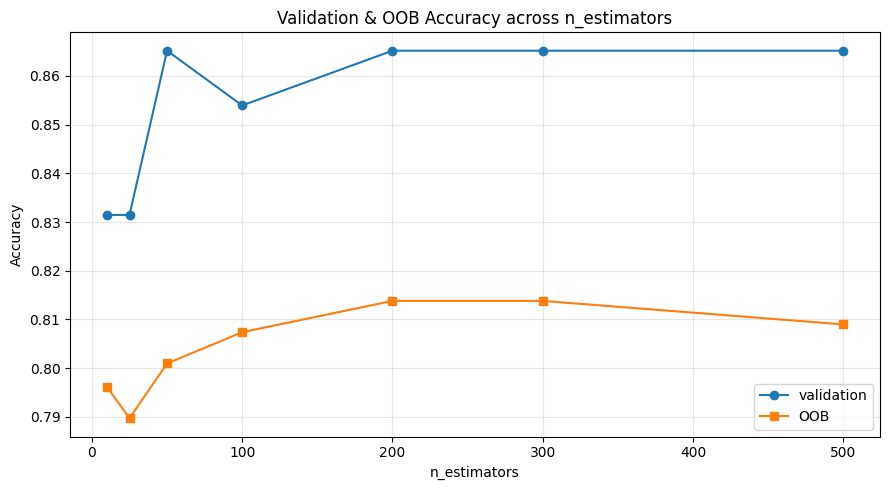

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(results_n_df["n_estimators"], results_n_df["val_acc"], "-o", label="validation")
ax.plot(results_n_df["n_estimators"], results_n_df["oob_acc"], "-s", label="OOB")

ax.set_xlabel("n_estimators")
ax.set_ylabel("Accuracy")
ax.set_title("Validation & OOB Accuracy across n_estimators")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
depth_values = [2, 3, 4, 5, 6, 8, 10, 12, None]  # None = grow fully
results_d = []

for depth in depth_values:
    model = RandomForestClassifier(n_estimators=300, max_depth=depth, random_state=SEED, n_jobs=-1, oob_score=True)
    model.fit(X_train_proc, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train_proc))
    val_acc = accuracy_score(y_val, model.predict(X_val_proc))

    results_d.append({"max_depth": depth if depth is not None else "None (full)", "train_acc": train_acc, "val_acc": val_acc, "oob_acc": model.oob_score_})

results_d_df = pd.DataFrame(results_d)
results_d_df


,max_depth,train_acc,val_acc,oob_acc
0,2,0.791332,0.786517,0.788122
1,3,0.825040,0.831461,0.805778
2,4,0.839486,0.831461,0.810594
3,5,0.855538,0.842697,0.813804
4,6,0.871589,0.853933,0.812199
5,8,0.922953,0.865169,0.821830
6,10,0.951846,0.853933,0.821830
7,12,0.967897,0.865169,0.820225
8,None (full),0.985554,0.865169,0.813804


Pick the smallest `n_estimators` where validation/OOB accuracy has flattened out (same "elbow, not the exact peak" reasoning as before -- more trees only add compute cost past that point), and the `max_depth` with the best validation accuracy.

In [15]:
tolerance = 0.005
best_val_acc_n = results_n_df["val_acc"].max()
candidates_n = results_n_df[results_n_df["val_acc"] >= best_val_acc_n - tolerance]
BEST_N_ESTIMATORS = int(candidates_n.sort_values("n_estimators").iloc[0]["n_estimators"])

best_row_d = results_d_df.sort_values("val_acc", ascending=False).iloc[0]
BEST_MAX_DEPTH = best_row_d["max_depth"]
BEST_MAX_DEPTH = None if BEST_MAX_DEPTH == "None (full)" else int(BEST_MAX_DEPTH)

print(f"Selected n_estimators: {BEST_N_ESTIMATORS}")
print(f"Selected max_depth   : {BEST_MAX_DEPTH}")


Selected n_estimators: 50
Selected max_depth   : 12


## 9. Final Evaluation on the Held-Out Test Set

In [16]:
final_rf = RandomForestClassifier(
    n_estimators=BEST_N_ESTIMATORS,
    max_depth=BEST_MAX_DEPTH,
    random_state=SEED,
    n_jobs=-1,
    oob_score=True,
)
final_rf.fit(X_train_proc, y_train)

test_preds = final_rf.predict(X_test_proc)
test_probs = final_rf.predict_proba(X_test_proc)[:, 1]

print("Test accuracy :", round(accuracy_score(y_test, test_preds), 4))
print("Test precision:", round(precision_score(y_test, test_preds), 4))
print("Test recall   :", round(recall_score(y_test, test_preds), 4))
print("Test F1       :", round(f1_score(y_test, test_preds), 4))
print("Test ROC AUC  :", round(roc_auc_score(y_test, test_probs), 4))
print()
print(classification_report(y_test, test_preds, target_names=["died", "survived"]))


Test accuracy : 0.8101
Test precision: 0.7778
Test recall   : 0.7101
Test F1       : 0.7424
Test ROC AUC  : 0.8184

              precision    recall  f1-score   support

        died       0.83      0.87      0.85       110
    survived       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



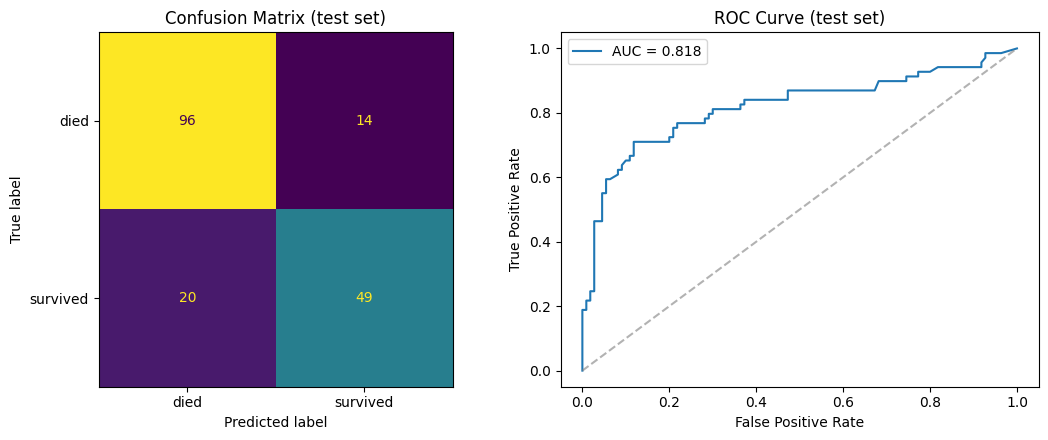

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(cm, display_labels=["died", "survived"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (test set)")

fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, test_probs):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray", alpha=0.6)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (test set)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 10. Feature Importances: Single Tree vs. Forest

A Random Forest's feature importance is the **average** of each tree's impurity-decrease importance across all trees in the forest. Because each tree only saw a bootstrap sample and a random subset of features per split, the forest's importances tend to be more **stable and less prone to a single tree's quirks** -- a lone tree might latch onto one feature and rate it artificially high just because it happened to make a good early split on this particular training sample; averaging over hundreds of trees smooths that out.

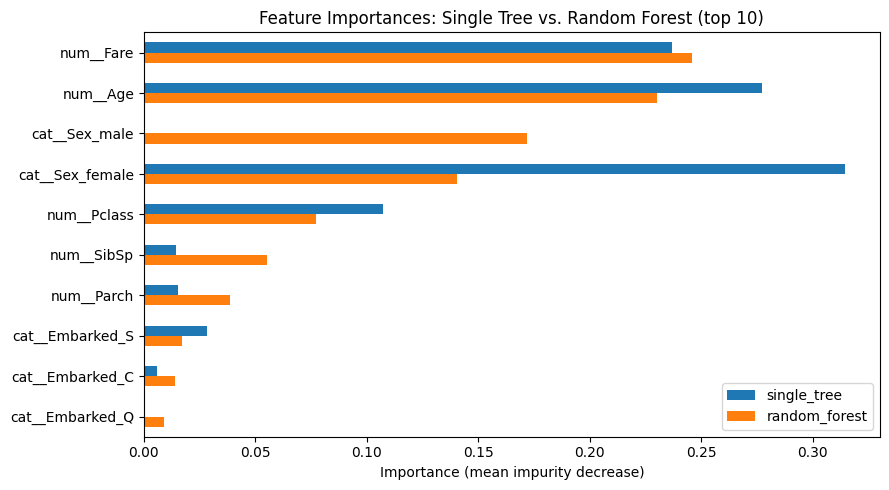

,single_tree,random_forest
num__Fare,0.236778,0.245900
num__Age,0.277383,0.230221
cat__Sex_male,0.000000,0.172123
cat__Sex_female,0.314556,0.140375
num__Pclass,0.107116,0.077453
num__SibSp,0.014636,0.055224
num__Parch,0.015118,0.038625
cat__Embarked_S,0.028474,0.017045
cat__Embarked_C,0.005939,0.013786
cat__Embarked_Q,0.000000,0.009248


In [18]:
single_tree = DecisionTreeClassifier(random_state=SEED)
single_tree.fit(X_train_proc, y_train)

importances_tree = pd.Series(single_tree.feature_importances_, index=feature_names_out, name="single_tree")
importances_forest = pd.Series(final_rf.feature_importances_, index=feature_names_out, name="random_forest")

comparison = pd.concat([importances_tree, importances_forest], axis=1).sort_values("random_forest", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
comparison.head(10).plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Importance (mean impurity decrease)")
ax.set_title("Feature Importances: Single Tree vs. Random Forest (top 10)")
plt.tight_layout()
plt.show()

comparison


## 11. Inference on a New, Unseen Passenger

In [19]:
def predict_survival(raw_features: dict, model, preprocessor):
    input_df = pd.DataFrame([raw_features])
    input_proc = preprocessor.transform(input_df)
    pred = model.predict(input_proc)[0]
    prob = model.predict_proba(input_proc)[0, 1]
    return pred, prob


example_passenger = {
    "Pclass": 3,
    "Sex": "male",
    "Age": 22,
    "SibSp": 1,
    "Parch": 0,
    "Fare": 7.25,
    "Embarked": "S",
}

pred, prob = predict_survival(example_passenger, final_rf, preprocessor)
print(f"Predicted: {'survived' if pred == 1 else 'died'} (P(survived) = {prob:.3f})")


Predicted: died (P(survived) = 0.140)


## 12. Save the Model (optional)

In [20]:
joblib.dump({"model": final_rf, "preprocessor": preprocessor}, "titanic_rf_classifier.joblib")
print("Model + preprocessor saved to titanic_rf_classifier.joblib")

# To reload later:
# bundle = joblib.load("titanic_rf_classifier.joblib")
# final_rf, preprocessor = bundle["model"], bundle["preprocessor"]


Model + preprocessor saved to titanic_rf_classifier.joblib
